# Assignment 7

# One Dataset, Three Weapons 

I choose **Loan Approval Prediction** Dataset

Objective:
Predict whether a loan application will be approved or rejected based on applicant information.

Dataset:
Kaggle Loan Prediction Dataset

# Tasks 

## Part A — Data Preparation

In [1]:
# Data Manipulation
import pandas as pd

# Numerical Computation
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis
import scipy.stats as stats

In [2]:
df = pd.read_csv('Loan Approval dataset.csv')
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
df.shape

(981, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            981 non-null    object 
 1   Gender             957 non-null    object 
 2   Married            978 non-null    object 
 3   Dependents         956 non-null    object 
 4   Education          981 non-null    object 
 5   Self_Employed      926 non-null    object 
 6   ApplicantIncome    981 non-null    int64  
 7   CoapplicantIncome  981 non-null    float64
 8   LoanAmount         954 non-null    float64
 9   Loan_Amount_Term   961 non-null    float64
 10  Credit_History     902 non-null    float64
 11  Property_Area      981 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 99.8+ KB


In [5]:
# summary statistics
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,981.000000,981.000000,954.000000,961.000000,902.000000
mean,5179.795107,1601.916330,142.511530,342.201873,0.835920
std,5695.104533,2718.772806,77.421743,65.100602,0.370553
min,0.000000,0.000000,9.000000,6.000000,0.000000
25%,2875.000000,0.000000,100.000000,360.000000,1.000000
50%,3800.000000,1110.000000,126.000000,360.000000,1.000000
75%,5516.000000,2365.000000,162.000000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


In [6]:
# check Missing values
print("Missing values per columns")
df.isnull().sum()/len(df)*100

Missing values per columns


Loan_ID               0.000000
Gender                2.446483
Married               0.305810
Dependents            2.548420
Education             0.000000
Self_Employed         5.606524
ApplicantIncome       0.000000
CoapplicantIncome     0.000000
LoanAmount            2.752294
Loan_Amount_Term      2.038736
Credit_History        8.053007
Property_Area         0.000000
Loan_Status          37.410805
dtype: float64

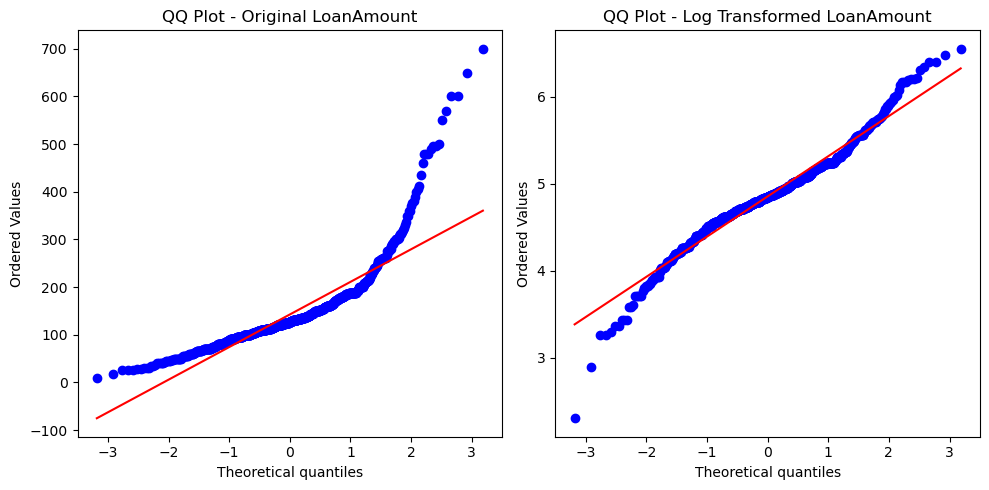

In [7]:


# Log Transformation
df['LoanAmount_log'] = np.log1p(df['LoanAmount'])

# Create side-by-side QQ plots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original LoanAmount
stats.probplot(
    df['LoanAmount'].dropna(), dist="norm",plot=axes[0])
axes[0].set_title("QQ Plot - Original LoanAmount")

# Log-transformed LoanAmount
stats.probplot(df['LoanAmount_log'].dropna(),dist="norm",plot=axes[1])
axes[1].set_title("QQ Plot - Log Transformed LoanAmount")

plt.tight_layout()
plt.show()

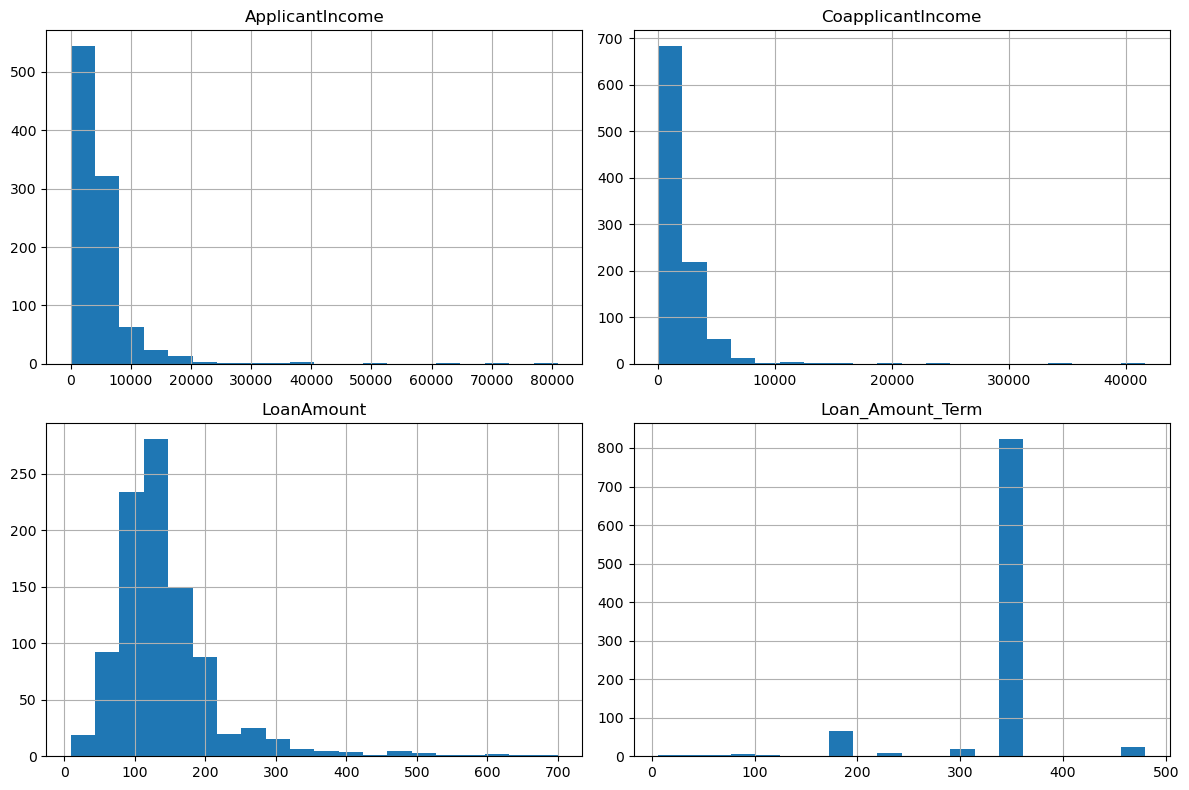

In [8]:
numerical_cols = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'Loan_Amount_Term'
]

df[numerical_cols].hist(
    figsize=(12,8),
    bins=20
)

plt.tight_layout()
plt.show()

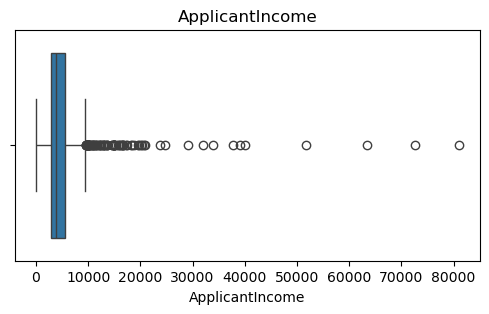

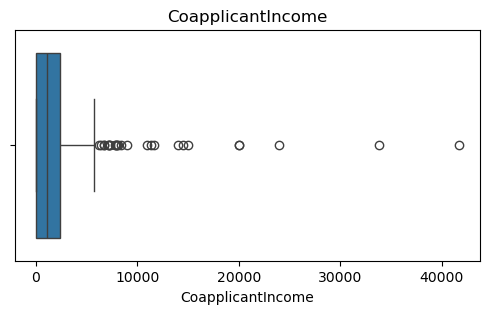

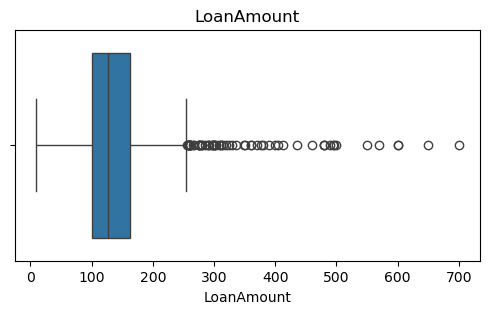

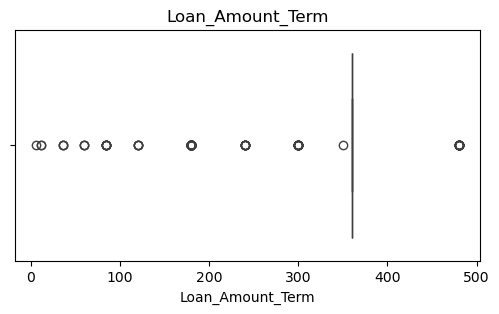

In [9]:
for col in numerical_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

# Part B - Linear Regression

### Target variable: Loan Amount (Numerical)

In [10]:
# Preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Pipeline
from sklearn.pipeline import Pipeline

# Split data
from sklearn.model_selection import train_test_split

# Model
from sklearn.linear_model import LinearRegression

# Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [11]:
df['LoanAmount'].isnull().sum()

np.int64(27)

In [12]:
df = df.dropna(subset=['LoanAmount'])

In [13]:
df['LoanAmount'].isnull().sum()

np.int64(0)

#### Define Features and Target

In [14]:
# Features
X = df.drop(['LoanAmount', 'Loan_ID'], axis=1)
# Target
y = df['LoanAmount']

In [15]:
# Identify Numerical Features
numeric_features = X.select_dtypes(include=['int64','float64']).columns
# Identify Categorical Features
categorical_features = X.select_dtypes(include=['object']).columns

# Numerical Data Pipeline and Handle Missing Values
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Data Pipeline and Fill Missing Categories
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine Both Pipelines
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


In [16]:
# Split the Data (Train-Test split) 
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(763, 12)
(191, 12)
(763,)
(191,)


In [17]:
# Creates the Linear Regression model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['ApplicantIncome', 'CoapplicantIncome', 'Loan_Amount_Term',
       'Credit_History', 'LoanAmount_log'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='object'))])),
                ('regressor', LinearRegression())])

In [18]:
# Model Predictions
y_pred = model.predict(X_test)

#### Model  Evaluation 

In [19]:
# MAE (Mean Absolute Error)
mae = mean_absolute_error(y_test, y_pred)

# RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R² Score (Coefficient of Determination)
r2 = r2_score(y_test, y_pred)

# Adjusted R²
n = len(y_test)
p = X_train.shape[1]

adj_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))


print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)
print("Adjusted R²:",adj_r2)

MAE: 16.656818275930775
RMSE: 30.06097512809315
R² Score: 0.7938450620571288
Adjusted R²: 0.779946976353115


In [20]:
# Get Feature Names After Preprocessing
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
# Get Linear Regression Coefficients
coefficients = model.named_steps['regressor'].coef_
# Create DataFrame
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})
# Sort by Coefficient
coef_df = coef_df.sort_values('Coefficient', ascending=False)

display
coef_df.head(10)

,Feature,Coefficient
4,num__LoanAmount_log,64.944343
0,num__ApplicantIncome,16.551657
1,num__CoapplicantIncome,3.156683
3,num__Credit_History,2.557524
19,cat__Property_Area_Urban,2.140316
5,cat__Gender_Female,1.757228
20,cat__Loan_Status_N,1.357405
16,cat__Self_Employed_Yes,1.145106
11,cat__Dependents_2,0.706101
8,cat__Married_Yes,0.684985


# Interpretation
Most influential numerical features:

The model suggests that loan amount and applicant income are the strongest drivers of predictions. Applicants with higher income, larger loan amounts, better credit history, and certain property characteristics tend to receive higher predicted outcomes. Demographic variables such as gender, marital status, and dependents have comparatively smaller effects

# Part C — Logistic Regression  

## Target variable: Loan_Status (Categorical)

In [21]:
# Preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Pipeline
from sklearn.pipeline import Pipeline

# Split data
from sklearn.model_selection import train_test_split

# Model
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve

In [22]:
df['Loan_Status'].isnull().sum()

np.int64(362)

In [23]:
df = df.dropna(subset=['Loan_Status'])

In [24]:
df['Loan_Status'].isnull().sum()

np.int64(0)

#### Define Features and Target

In [25]:
# Features
X = df.drop(['Loan_Status', 'Loan_ID'], axis=1)
# Target
y = df['Loan_Status']


In [26]:
# Identify Numerical Features
numeric_features = X.select_dtypes(include=['int64','float64']).columns
# Identify Categorical Features
categorical_features = X.select_dtypes(include=['object']).columns

# Numerical Data Pipeline and Handle Missing Values
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Data Pipeline and Fill Missing Categories
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine Both Pipelines
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


In [27]:
# Split the Data (Train-Test split) 
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(473, 12)
(119, 12)
(473,)
(119,)


In [28]:
# Creates the Logistic Regression model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'LoanAmount_log'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area'],
      dtype='object'))])),
                ('classifier', LogisticRegression())])

In [29]:
# Model Predictions
y_pred = model.predict(X_test)

#### Model Evaluation

In [30]:
# Model Accuracy
accuracy_lr = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy_lr,3))

Model Accuracy: 0.798


In [31]:
# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           N       0.90      0.45      0.60        40
           Y       0.78      0.97      0.87        79

    accuracy                           0.80       119
   macro avg       0.84      0.71      0.73       119
weighted avg       0.82      0.80      0.78       119



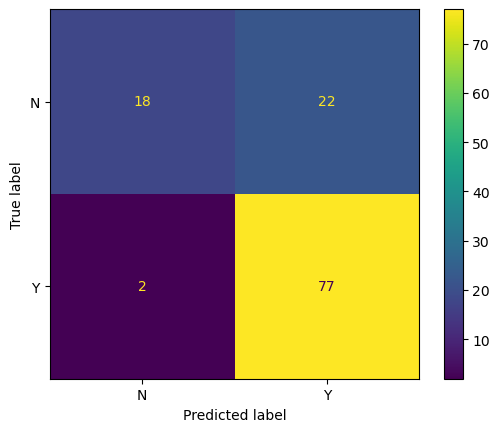

In [32]:
# confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

ROC-AUC: 0.7518987341772152


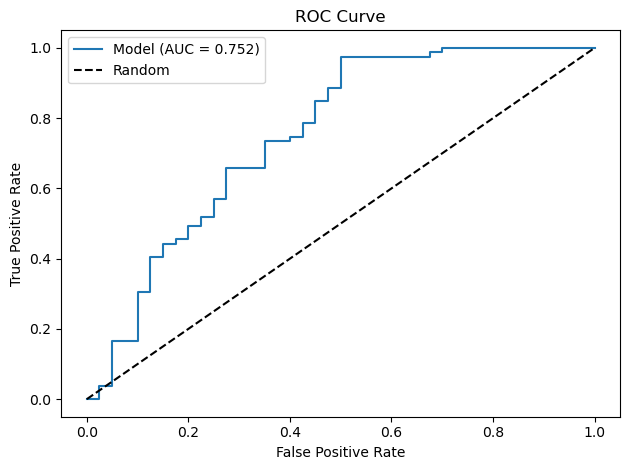

In [33]:

# Predicted probabilities (important for ROC-AUC)
y_scores = model.predict_proba(X_test)[:, 1]

# Compute ROC-AUC
auc = roc_auc_score(y_test, y_scores)
print("ROC-AUC:", auc)

# Generate ROC Curve Points
fpr, tpr, thresholds = roc_curve(y_test, y_scores, pos_label='Y')

# Plot ROC Curve
plt.plot(fpr, tpr, label=f"Model (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
# Get Feature Names After Preprocessing
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
# Get Linear Regression Coefficients
coefficients = model.named_steps['classifier'].coef_.flatten()
# Create DataFrame
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})
# Sort by Coefficient
coef_df = coef_df.sort_values('Coefficient', ascending=False)
coef_df['Impact'] = np.exp(coef_df['Coefficient'])
# display
coef_df.head(10)

,Feature,Coefficient,Impact
4,num__Credit_History,1.373055,3.947393
19,cat__Property_Area_Semiurban,0.584113,1.793399
13,cat__Dependents_3+,0.274997,1.316526
9,cat__Married_Yes,0.271294,1.311660
12,cat__Dependents_2,0.203652,1.225871
14,cat__Education_Graduate,0.143960,1.154838
7,cat__Gender_Male,0.107547,1.113544
5,num__LoanAmount_log,0.055803,1.057389
16,cat__Self_Employed_No,0.046977,1.048098
0,num__ApplicantIncome,0.038364,1.039109


# overall Interpretation:

The model shows that Credit History is the strongest factor influencing loan approval probability. Applicants with a good credit record are much more likely to be approved. Other variables such as education, marital status, property area, and employment type have smaller effects. Financial reliability and repayment history are more influential than demographic factors.

Probability Effect:
 - Positive coefficient → increases probability of loan approval (Y)
 - Negative coefficient → increases probability of loan rejection (N)

In this model, the strongest positive driver is:
    Credit_History → Higher chance of approval

# Part D — Support Vector Classifier (SVC)

### Target variable: Loan_Status (Categorical)

In [35]:
# Preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Pipeline
from sklearn.pipeline import Pipeline

# Split data
from sklearn.model_selection import train_test_split

# Model
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve

### Define Features and Target

In [36]:
# Features
X = df.drop(['Loan_Status', 'Loan_ID'], axis=1)
# Target
y = df['Loan_Status']


In [37]:
# Identify Numerical Features
numeric_features = X.select_dtypes(include=['int64','float64']).columns
# Identify Categorical Features
categorical_features = X.select_dtypes(include=['object']).columns

# Numerical Data Pipeline and Handle Missing Values
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Data Pipeline and Fill Missing Categories
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine Both Pipelines
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


In [38]:
# Split the Data (Train-Test split) 
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(473, 12)
(119, 12)
(473,)
(119,)


In [39]:
# Creates the  Support Vector Classifier (SVC) model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
        ('classifier', SVC(kernel = 'linear', probability=True, gamma = 0.001,random_state = 42))
])

model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'LoanAmount_log'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area'],
      dtype='object'))])),
                ('classifier',
                 SVC(gamma=0.001, kernel='linear', probability=True,
                     random_state=42))])

In [40]:
# Model Predictions
y_pred_svc = model.predict(X_test)

In [41]:
# Model Accuracy
accuracy_svc = accuracy_score(y_test, y_pred_svc)
print("Model Accuracy:", accuracy_svc)

Model Accuracy: 0.7899159663865546


In [42]:
# Classification Report
svc_cr = classification_report(y_test, y_pred_svc)
print("\nClassification Report:\n", svc_cr)


Classification Report:
               precision    recall  f1-score   support

           N       0.89      0.42      0.58        40
           Y       0.77      0.97      0.86        79

    accuracy                           0.79       119
   macro avg       0.83      0.70      0.72       119
weighted avg       0.81      0.79      0.76       119



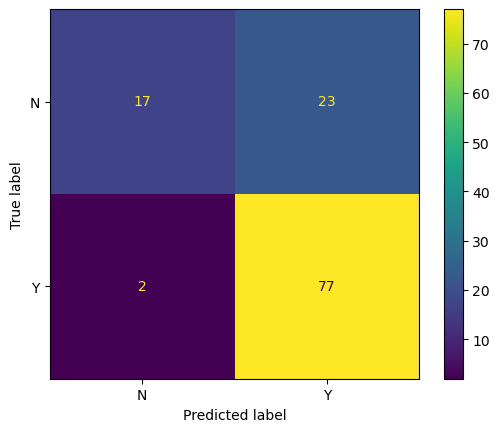

In [43]:
# ConfusionMatrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svc)
plt.show()

ROC-AUC: 0.7199367088607594


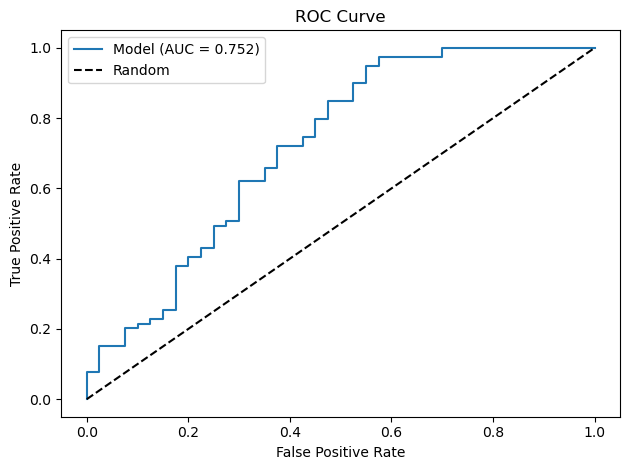

In [44]:

# Predicted probabilities (important for ROC-AUC)
y_scores = model.predict_proba(X_test)[:, 1]

# Compute ROC-AUC
auc_svc = roc_auc_score(y_test, y_scores)
print("ROC-AUC:", auc_svc)

# Generate ROC Curve Points
fpr, tpr, thresholds = roc_curve(y_test, y_scores, pos_label='Y')

# Plot ROC Curve
plt.plot(fpr, tpr, label=f"Model (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [45]:
# Get Feature Names After Preprocessing
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
# Get Linear Regression Coefficients
coefficients = model.named_steps['classifier'].coef_.flatten()
# Create DataFrame
top_features = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})
# Sort by Coefficient
coef_df = top_features.sort_values('Coefficient', ascending=False)
coef_df['Impact'] = np.exp(top_features['Coefficient'])
# display
coef_df.head(10)



,Feature,Coefficient,Impact
4,num__Credit_History,0.693087,1.999880
5,num__LoanAmount_log,0.000267,1.000267
14,cat__Education_Graduate,0.000073,1.000073
9,cat__Married_Yes,0.000054,1.000054
12,cat__Dependents_2,0.000037,1.000037
20,cat__Property_Area_Urban,0.000033,1.000033
17,cat__Self_Employed_Yes,0.000020,1.000020
19,cat__Property_Area_Semiurban,0.000015,1.000015
7,cat__Gender_Male,0.000012,1.000012
10,cat__Dependents_0,0.000011,1.000011


# overall Interpretation:

The model shows that Credit History is the strongest factor influencing loan approval probability. Applicants with a good credit record are much more likely to be approved. Other variables such as education, marital status, property area, and employment type have smaller effects. Financial reliability and repayment history are more influential than demographic factors.

Probability Effect:
 - Positive coefficient → increases probability of loan approval (Y)
 - Negative coefficient → increases probability of loan rejection (N)

In this model, the strongest positive driver is:
    Credit_History → Higher chance of approval

## Part E — Model Comparison & Recommendation 

In [46]:
print("Target variable: Loan Amount (Numerical)")
final_numerical  = pd.DataFrame({
    'Model': ['Linear Regression'],
    'MAE': [mae],
    'R2': [r2],
    'RMSE': [rmse],
    'Adjusted R2': [adj_r2]
})

display(final_numerical.round(4))

report_lr =   classification_report(y_test, y_pred ,output_dict=True)
report_svc =   classification_report(y_test, y_pred_svc,output_dict=True)
print("\nTarget variable: Loan_Status (Categorical)")
final_categorical = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVC'],
    'Accuracy': [accuracy_lr, accuracy_svc],
    'Precision': [report_lr['weighted avg']['precision'],
                  report_svc['weighted avg']['precision']],
    'Recall': [report_lr['weighted avg']['recall'],
               report_svc['weighted avg']['recall']],
    'F1-Score': [report_lr['weighted avg']['f1-score'],
                 report_svc['weighted avg']['f1-score']],
    'AUC': [auc, auc_svc]
})

display(final_categorical.round(4))

Target variable: Loan Amount (Numerical)


,Model,MAE,R2,RMSE,Adjusted R2
0,Linear Regression,16.6568,0.7938,30.061,0.7799



Target variable: Loan_Status (Categorical)


,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,Logistic Regression,0.7983,0.8189,0.7983,0.7760,0.7519
1,SVC,0.7899,0.8119,0.7899,0.7649,0.7199


# Compare all three models side by side:

| Criteria                    | Linear Regression (Loan Amount)                                           | Logistic Regression (Loan Status)                                                 | SVC (Loan Status)                                                                           |
| --------------------------- | ------------------------------------------------------------------------- | --------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------- |
| **Performance Metrics**     | MAE = 16.66,   RMSE = 30.06,  R² = 0.7938,  Adjusted R² = 0.7799              | Accuracy = 79.83%, Precision = 81.89%, Recall = 79.83%, F1 = 77.60%, AUC = 0.7519 | Accuracy = 78.99%, Precision = 81.19%, Recall = 78.99%, F1 = 76.49%, AUC = 0.7199           |
| **Ease of Interpretation**  | Very High – coefficients directly show impact of variables on loan amount | High – coefficients can be interpreted as effects on approval probability         | Low – decision boundary is difficult to interpret, especially with kernels                  |
| **Sensitivity to Outliers** | High – outliers can significantly affect regression coefficients          | Moderate – less sensitive than linear regression but can still be influenced      | Low to Moderate – generally more robust to outliers depending on kernel and hyperparameters |
| **Training Complexity**     | Low – fast training and implementation                                    | Low – computationally efficient and scalable                                      | Moderate to High – training becomes computationally expensive for larger datasets           |
| **Reliability**             | Stable when assumptions are met                                           | Stable and consistent for binary classification problems                          | Can achieve strong performance but requires careful parameter tuning                        |


# Recommended Model: Logistic Regression

Logistic Regression is recommended for deployment because it provides the best balance between accuracy, interpretability, and reliability.

Reasons:

1. Performance:
- Logistic Regression achieved the highest accuracy (79.83%).
- It also achieved better Precision, Recall, and F1-score compared to SVC.

2. Interpretability:
- The model coefficients clearly show how each feature affects loan approval.
- Important factors such as Credit History, Income, and Loan Amount can be explained to business users.

3. Reliability:
- Logistic Regression is less complex and easier to maintain.
- It trains quickly and works well with structured tabular data.

4. Comparison with SVC:
- SVC achieved slightly lower accuracy (78.99%).
- It is more complex and harder to interpret, which is important in financial applications.

5. Linear Regression:
- Linear Regression performs well for predicting Loan Amount (R² = 0.7938).
- However, it cannot be used for Loan Approval classification.

# Model Deployment Recommendation

After comparing Linear Regression, Logistic Regression, and SVC, **Logistic Regression is recommended for deployment**.

### Reasons:

1. **Accuracy**
- Logistic Regression achieved the highest classification accuracy (**79.83%**).
- It also achieved better Precision, Recall, and F1-score compared to SVC.
- This makes it more reliable for predicting loan approval status.

2. **Interpretability**
- Logistic Regression is easy to understand because it provides feature coefficients.
- We can identify which factors influence loan approval, such as:
  - Credit History
  - Applicant Income
  - Loan Amount
- This helps explain decisions to customers and banking teams.

3. **Reliability**
- Logistic Regression is simple, fast, and requires less computational power.
- It performs well on structured data like loan applications.
- It is easier to maintain and update compared to SVC.

4. **Comparison with Other Models**
- Linear Regression works well for predicting Loan Amount but cannot classify loan approval.
- SVC provides similar performance but is more complex and harder to interpret.

### Final Decision:

For deployment, **Linear Regression** should be used for **Loan Amount prediction**, and **Logistic Regression** should be used for **Loan Status classification**. These models provide the best balance of:

Accuracy – Competitive predictive performance.
Interpretability – Clear understanding of feature impacts, which is crucial in financial applications.
Reliability – Stable performance with lower computational requirements and easier maintenance.
Regulatory Compliance – Transparent decision-making processes are preferred in lending environments.

Therefore, Linear Regression and Logistic Regression are the preferred deployment choices, as they offer strong predictive performance while maintaining explainability and operational efficiency.